In [210]:
using CSV
using DataFrames
using Polynomials
using CairoMakie
using Statistics

In [211]:
include("D:/01 Projekt/03 Programm/Rini aktuell/Rini/src/TIRA.jl")

Main.TIRA

## Literature properties

### Polyimide

In [212]:
BaseName="D:/01 Projekt/03 Programm/Rini aktuell/Rini/development/05 MaterialienDataBase/Polyimide/Dharmadasa2020.csv"

df_Dharmadasa2020 = CSV.read(BaseName, DataFrame;
    delim=',',
    decimal='.'
);

BaseName="D:/01 Projekt/03 Programm/Rini aktuell/Rini/development/05 MaterialienDataBase/Polyimide/Seonho2022.csv"

df_Seonho2022 = CSV.read(BaseName, DataFrame;
    delim=';',
    decimal=','
);

BaseName="D:/01 Projekt/03 Programm/Rini aktuell/Rini/development/05 MaterialienDataBase/Polyimide/Kuo2005_0_6.csv"

df_Kuo2005_0_6 = CSV.read(BaseName, DataFrame;
    delim=';',
    decimal=','
);

BaseName="D:/01 Projekt/03 Programm/Rini aktuell/Rini/development/05 MaterialienDataBase/Polyimide/Kuo2005_60.csv"

df_Kuo2005_60 = CSV.read(BaseName, DataFrame;
    delim=';',
    decimal=','
);

In [213]:
fig = Figure(resolution = (1000, 600));

font=42
ax1 = Axis(fig[1,1],
    xlabel = L"\epsilon (%)",
    ylabel = L"\sigma (MPa)",
    xlabelsize = font,
    ylabelsize = font,
    xticklabelsize = font - 2,
    yticklabelsize = font - 2,
    xgridstyle = :dash,        # dashed grid
    ygridstyle = :dash,
    xgridvisible = false,
    ygridvisible = false,
    limits = (nothing,(0, 220)))



Axis with 0 plots:


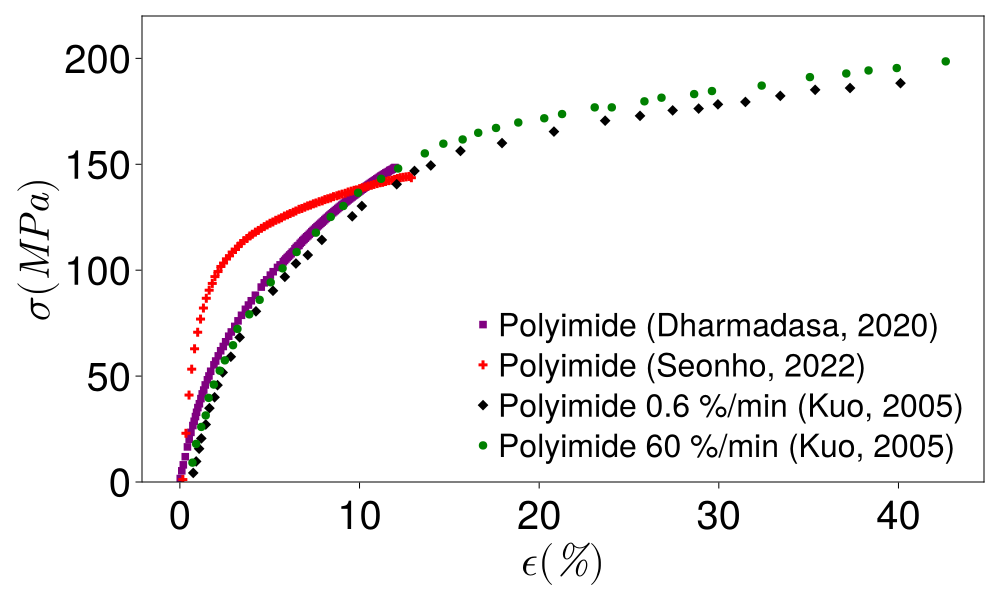

In [214]:
    Makie.scatter!(ax1,df_Dharmadasa2020[!,1]*100,df_Dharmadasa2020[!,2];
      label = "Polyimide (Dharmadasa, 2020)",
      marksize=10,
      color = :purple,
      clip = true,
      marker = :rect)

    Makie.scatter!(ax1,df_Seonho2022[!,1],df_Seonho2022[!,2];
      label = "Polyimide (Seonho, 2022)",
      marksize=10,
      color = :red,
      clip = true,
      marker = :cross)


    Makie.scatter!(ax1,df_Kuo2005_0_6[!,1],df_Kuo2005_0_6[!,2];
      label = "Polyimide 0.6 %/min (Kuo, 2005)",
      marksize=10,
      color = :black,
      clip = true,
      marker = :diamond)

    Makie.scatter!(ax1,df_Kuo2005_60[!,1],df_Kuo2005_60[!,2];
      label = "Polyimide 60 %/min (Kuo, 2005)",
      marksize=10,
      color = :green,
      clip = true,
      marker = :circle)
     axislegend(ax1, labelsize=font-10, framevisible=false,position = :rb)
      fig

### Parylene

In [215]:
figParylene = Figure(resolution = (1000, 600));

font=42
axParylene = Axis(figParylene[1,1],
    xlabel = L"\epsilon (%)",
    ylabel = L"\sigma (MPa)",
    xlabelsize = font,
    ylabelsize = font,
    xticklabelsize = font - 2,
    yticklabelsize = font - 2,
    xgridstyle = :dash,        # dashed grid
    ygridstyle = :dash,
    xgridvisible = false,
    ygridvisible = false,
    limits = (nothing,(0, 75)))


Axis with 0 plots:


In [216]:
BaseName="D:/01 Projekt/03 Programm/Rini aktuell/Rini/development/05 MaterialienDataBase/Parylene/Kang2013_9um_20T.csv"

df_Kang2013 = CSV.read(BaseName, DataFrame;
    delim=';',
    decimal=','
);


BaseName="D:/01 Projekt/03 Programm/Rini aktuell/Rini/development/05 MaterialienDataBase/Parylene/Kohler2023.csv"

df_Kohler2023 = CSV.read(BaseName, DataFrame;
    delim=';',
    decimal=','
);



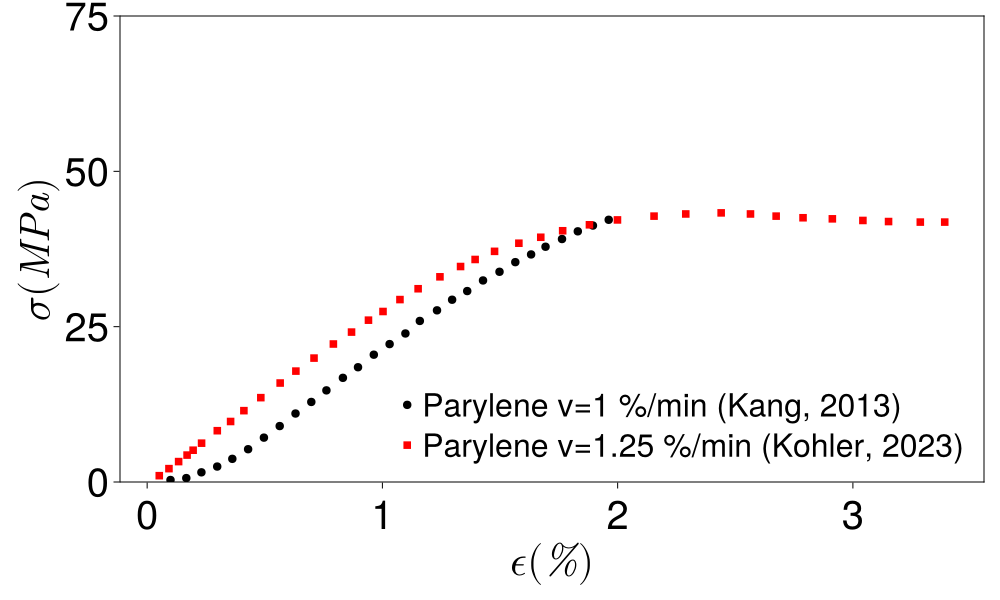

In [217]:
  Makie.scatter!(axParylene,df_Kang2013[!,1],df_Kang2013[!,2];
      label = "Parylene v=1 %/min (Kang, 2013)",
      marksize=10,
      color = :black,
      clip = true,
      marker = :circle)

  Makie.scatter!(axParylene,df_Kohler2023[!,1],df_Kohler2023[!,2];
      label = "Parylene v=1.25 %/min (Kohler, 2023)",
      marksize=10,
      color = :red,
      clip = true,
      marker = :rect)
     axislegend(axParylene, labelsize=font-10, framevisible=false,position = :rb)
      figParylene

### Unseres Parylene



In [218]:
include("D:/01 Projekt/03 Programm/Rini aktuell/Rini/src/TIRA.jl")

Main.TIRA

#### Mechanische Eigenschaften

In [219]:
#Temperatur Einfluss

## Geometrie
w=10*1e-3 # Width
t=15*1e-6 # thickness
l=60*1e-3 # length
As=w*t    # stress section

## Room 27 %/min

BaseName="D:/01 Projekt/03 Programm/Rini aktuell/Rini/development/04 zugversuch/AP5ZK04/251103-"
name="251103-"

DataProperties=[]
df_Data=[]
for i in [1]
        
        df=TIRA.computeStressStrain(BaseName,name,i,22,As)
        df=TIRA.filter_range(df,"dL_ORG",0,10)
        properties=TIRA.computeProperties(df,[0.1 0.5],[0 100])
        push!(DataProperties,properties)
        push!(df_Data,df)
end

## 50 27 %/min

BaseName="D:/01 Projekt/03 Programm/Rini aktuell/Rini/development/04 zugversuch/AP5ZK04/251103-"
name="251103-"

for i in [7]

        df=TIRA.computeStressStrain(BaseName,name,i,50,As)
        df=TIRA.filter_range(df,"dL_ORG",0,10)
        properties=TIRA.computeProperties(df,[0.1 0.5],[0 100])
        push!(DataProperties,properties)
        push!(df_Data,df)
end

## 100 27 %/min

BaseName="D:/01 Projekt/03 Programm/Rini aktuell/Rini/development/04 zugversuch/AP5ZK04/251103-"
name="251103-"

for i in [10]

        df=TIRA.computeStressStrain(BaseName,name,i,100,As)
        df=TIRA.filter_range(df,"dL_ORG",0,10)
        properties=TIRA.computeProperties(df,[1.2 2],[0 100])
        push!(DataProperties,properties)
        push!(df_Data,df)
end

In [220]:
#Strain Rate Einfluss
##### Strain Rate 1.43 %/min

BaseName="D:/01 Projekt/03 Programm/Rini aktuell/Rini/development/04 zugversuch/AP5ZK03/251006-0"
name="251006-"

for i in [1]

    df=TIRA.computeStressStrain(BaseName,name,i,22,As)
    df=TIRA.filter_range(df,"dL_ORG",0,50)
    properties=TIRA.computeProperties(df,[0.1 0.5],[0 100])
    push!(DataProperties,properties)
    push!(df_Data,df)
        
end

##### Strain Rate 4.44 %/min

BaseName="D:/01 Projekt/03 Programm/Rini aktuell/Rini/development/04 zugversuch/AP5ZK03/251006-0"
name="251006-"

for i in [6]

    df=TIRA.computeStressStrain(BaseName,name,i,22,As)
    df=TIRA.filter_range(df,"dL_ORG",0,50)
    properties=TIRA.computeProperties(df,[0.1 0.4],[0 100])
    push!(DataProperties,properties)
    push!(df_Data,df)

end


df_DataProperties=DataFrame(DataProperties)

Row,e_max[%],δ_F/δ_B,Probe,δ_B,LinearRange [%],u_E[%],Temperature [C],E[GPa],sigmaMax,sigma0_25%,Strain Rate[%/min]
,Float64,Float64,String,Float64,Array…,Float64,Int64,Float64,Float64,Float64,Float64
1,4.18143,20.9205,251103-1,2.39,"[0.11, 0.5]",0.625591,22,4.00365,69.4667,24.6,27.087
2,6.81288,21.645,251103-7,2.31,"[0.1, 0.5]",0.805889,50,2.64315,35.7333,14.3333,24.4739
3,3.12264,71.8412,251103-10,2.77,"[1.2, 1.99]",0.869729,100,1.32388,25.5333,19.8,25.0633
4,1.84633,23.8546,251006-1,2.0931,"[0.1009, 0.4993]",0.0598597,22,3.19206,49.28,20.82,1.42775
5,4.43585,17.0213,251006-6,2.35,"[0.1, 0.4]",0.241171,22,3.56412,56.4667,15.7333,4.41855


#### Temperatur Einfluss

In [221]:
figTemperature = Figure(resolution = (1000, 600));

axTemperature = Axis(figTemperature[1,1],
    xlabel = L"\epsilon (%)",
    ylabel = L"\sigma (MPa)",
    xlabelsize = font,
    ylabelsize = font,
    xticklabelsize = font - 2,
    yticklabelsize = font - 2,
    xgridstyle = :dash,        # dashed grid
    ygridstyle = :dash,
    xgridvisible = false,
    ygridvisible = false
)


Axis with 0 plots:


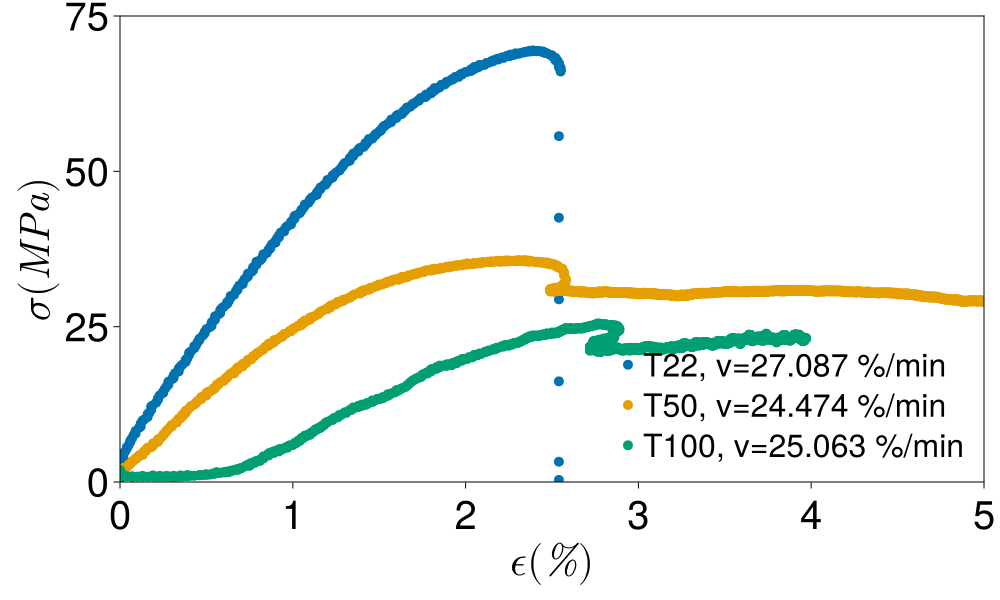

In [222]:
for i in [1 2 3]
    df=df_Data[i]
    df_Properties=df_DataProperties[i,:]
    Makie.scatter!(axTemperature ,df[!,:Strain],df[!,:Stress];
    markersize=14, 
    label = "T$(df_Properties["Temperature [C]"]), v=$(round(df_Properties[" Strain Rate[%/min]"], digits=3)) %/min")
    limits!(axTemperature, 0, 5, 0, 75)
end

axislegend(axTemperature, labelsize=font-10, framevisible=false,position = :rb)
figTemperature

#### Strain Rate Einfluss

In [223]:
## Fig3 Strain Rate Einfluss
figStrainRate = Figure(resolution = (1000, 600));
axStrainRate = Axis(figStrainRate[1,1],
    xlabel = L"\epsilon (%)",
    ylabel = L"\sigma (MPa)",
    xlabelsize = font,
    ylabelsize = font,
    xticklabelsize = font - 2,
    yticklabelsize = font - 2,
    xgridstyle = :dash,        # dashed grid
    ygridstyle = :dash,
    xgridvisible = false,
    ygridvisible = false
)

Axis with 0 plots:


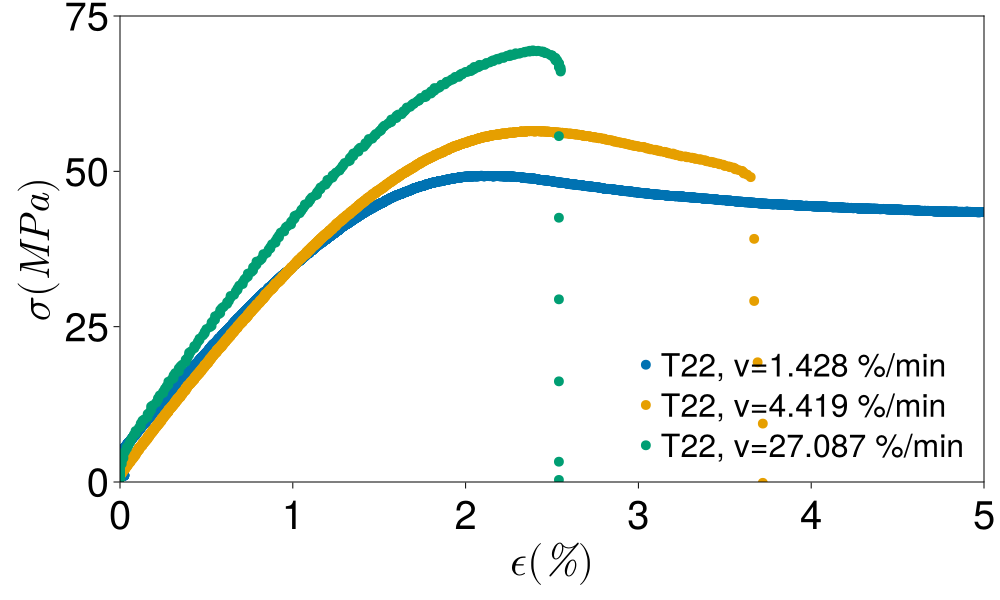

In [224]:
for i in [4 5 1]
    df=df_Data[i]
    df_Properties=df_DataProperties[i,:]
    Makie.scatter!(axStrainRate ,df[!,:Strain],df[!,:Stress];
    markersize=14, 
    label = "T22, v=$(round(df_Properties[" Strain Rate[%/min]"], digits=3)) %/min")
    limits!(axStrainRate, 0, 5, 0, 75)
end

axislegend(axStrainRate, labelsize=font-10, framevisible=false,position = :rb)
figStrainRate

### Vergleich 

#### mit Parylene

In [225]:
figParylene = Figure(resolution = (1000, 600));

font=42
axParylene = Axis(figParylene[1,1],
    xlabel = L"\epsilon (%)",
    ylabel = L"\sigma (MPa)",
    xlabelsize = font,
    ylabelsize = font,
    xticklabelsize = font - 2,
    yticklabelsize = font - 2,
    xgridstyle = :dash,        # dashed grid
    ygridstyle = :dash,
    xgridvisible = false,
    ygridvisible = false,
    limits = (nothing,(0, 75)))


Axis with 0 plots:


In [226]:
BaseName="D:/01 Projekt/03 Programm/Rini aktuell/Rini/development/05 MaterialienDataBase/Parylene/Kang2013_9um_20T.csv"

df_Kang2013 = CSV.read(BaseName, DataFrame;
    delim=';',
    decimal=','
);

BaseName="D:/01 Projekt/03 Programm/Rini aktuell/Rini/development/05 MaterialienDataBase/Parylene/Kohler2023.csv"

df_Kohler2023 = CSV.read(BaseName, DataFrame;
    delim=';',
    decimal=','
);



In [227]:
  Makie.scatter!(axParylene,df_Kang2013[!,1],df_Kang2013[!,2];
      label = "Parylene v=1 %/min (Kang, 2013)",
      marksize=10,
      color = :black,
      clip = true,
      marker = :circle)

  Makie.scatter!(axParylene,df_Kohler2023[!,1],df_Kohler2023[!,2];
      label = "Parylene v=1.25 %/min (Kohler, 2023)",
      marksize=10,
      color = :red,
      clip = true,
      marker = :rect)
      

Scatter{Tuple{Vector{Point{2, Float32}}}}

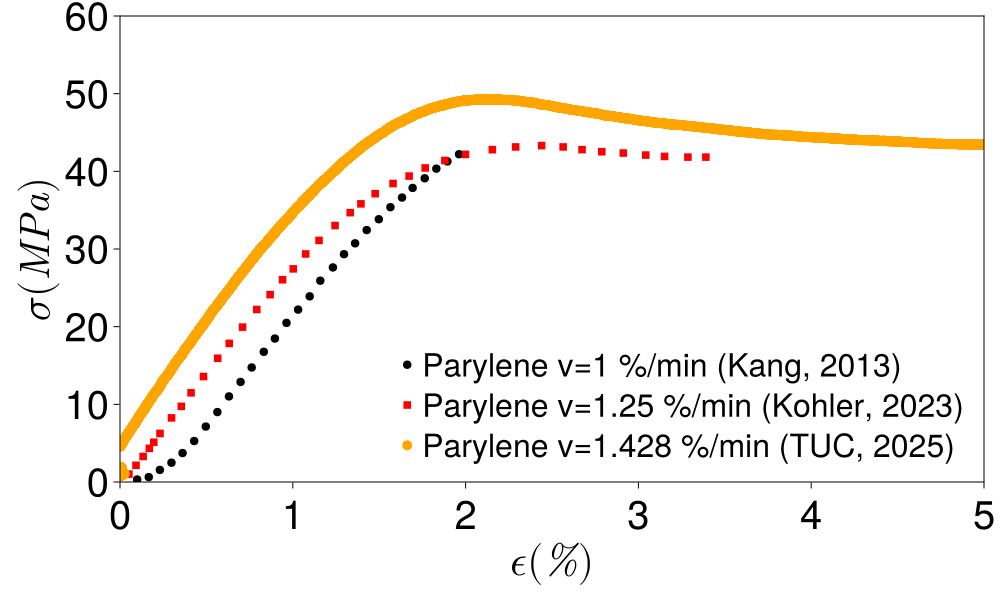

In [228]:
##### Strain Rate 1.43 %/min

  
for i in [4]
    df=df_Data[i]
    df_Properties=df_DataProperties[i,:]
    Makie.scatter!(axParylene ,df[!,:Strain],df[!,:Stress];
    markersize=14,
    color = :orange,
    label = "Parylene v=$(round(df_Properties[" Strain Rate[%/min]"], digits=3)) %/min (TUC, 2025)")
    limits!(axParylene, 0, 5, 0, 60)
end

axislegend(axParylene, labelsize=font-10, framevisible=false,position = :rb)
figParylene

#### mit Polyimide

In [229]:
fig = Figure(resolution = (1000, 600));

font=42
ax1 = Axis(fig[1,1],
    xlabel = L"\epsilon (%)",
    ylabel = L"\sigma (MPa)",
    xlabelsize = font,
    ylabelsize = font,
    xticklabelsize = font - 2,
    yticklabelsize = font - 2,
    xgridstyle = :dash,        # dashed grid
    ygridstyle = :dash,
    xgridvisible = false,
    ygridvisible = false,
    limits = (nothing,(0, 220)))



Axis with 0 plots:


In [230]:
    Makie.scatter!(ax1,df_Dharmadasa2020[!,1]*100,df_Dharmadasa2020[!,2];
      label = "PI (Dharmadasa, 2020)",
      marksize=10,
      color = :purple,
      clip = true,
      marker = :rect)

    Makie.scatter!(ax1,df_Seonho2022[!,1],df_Seonho2022[!,2];
      label = "PI(Seonho, 2022)",
      marksize=10,
      color = :red,
      clip = true,
      marker = :cross)


    Makie.scatter!(ax1,df_Kuo2005_0_6[!,1],df_Kuo2005_0_6[!,2];
      label = "PI 0.6 %/min (Kuo, 2005)",
      marksize=10,
      color = :black,
      clip = true,
      marker = :diamond)




Scatter{Tuple{Vector{Point{2, Float32}}}}

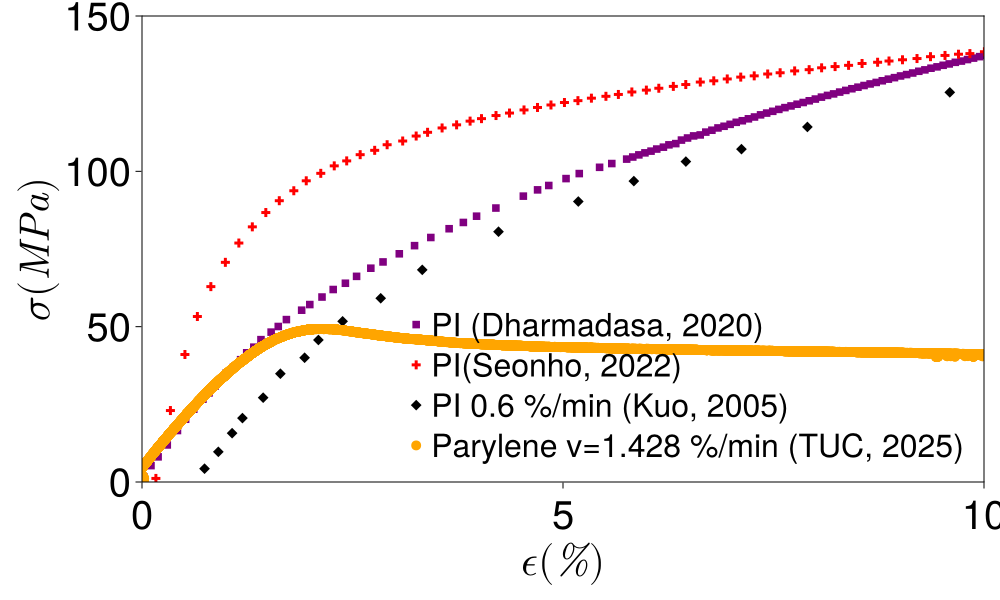

In [231]:
for i in [4]
    df=df_Data[i]
    df_Properties=df_DataProperties[i,:]
    Makie.scatter!(ax1 ,df[!,:Strain],df[!,:Stress];
    markersize=14,
    color = :orange,
    label = "Parylene v=$(round(df_Properties[" Strain Rate[%/min]"], digits=3)) %/min (TUC, 2025)")
    limits!(ax1, 0, 10, 0,150)
end

axislegend(ax1, labelsize=font-10, framevisible=false,position = :rb)
fig

## Fracture mechanics

In [232]:
figLaw = Figure(resolution = (1000, 600));

axLaw= Axis(figLaw[1,1],
    xlabel = L"logΔG (J/m2)",
    ylabel = L"log(\frac{\partial a}{\partial N}) (um/cycle)",
    xlabelsize = font,
    ylabelsize = font,
    xticklabelsize = font - 2,
    yticklabelsize = font - 2,
    xgridstyle = :dash,        # dashed grid
    ygridstyle = :dash,
    xgridvisible = false,
    ygridvisible = false
)


Axis with 0 plots:


In [233]:
BaseName="D:/01 Projekt/03 Programm/Rini aktuell/Rini/development/MaterialienDataBase/Fracture mechanics/PI_Cu_Walter2018.csv"

df_Walter2018 = CSV.read(BaseName, DataFrame;
    delim=';',
    decimal=','
);

ArgumentError: ArgumentError: "D:/01 Projekt/03 Programm/Rini aktuell/Rini/development/MaterialienDataBase/Fracture mechanics/PI_Cu_Walter2018.csv" is not a valid file or doesn't exist

In [234]:
df_Walter2018

UndefVarError: UndefVarError: `df_Walter2018` not defined

In [235]:
    Makie.scatter!(axLaw,log10.(df_Walter2018[!,1]),log10.(df_Walter2018[!,2]*1000);
      label = "PI-Cu (Walter, 2018)",
      marksize=10,
      color = :black,
      clip = true,
      marker = :circle)
     axislegend(axParylene, labelsize=font-10, framevisible=false,position = :rb)
      figLaw

UndefVarError: UndefVarError: `df_Walter2018` not defined

In [236]:
BaseName="D:/01 Projekt/03 Programm/Rini aktuell/Rini/development/MaterialienDataBase/Fracture mechanics/SiN_PI_Zhu2010.csv"

df_Zhu2010 = CSV.read(BaseName, DataFrame;
    delim=';',
    decimal=','
);

ArgumentError: ArgumentError: "D:/01 Projekt/03 Programm/Rini aktuell/Rini/development/MaterialienDataBase/Fracture mechanics/SiN_PI_Zhu2010.csv" is not a valid file or doesn't exist

In [237]:
    Makie.scatter!(axLaw,log10.(df_Zhu2010[!,1]),log10.(df_Zhu2010[!,2]*100000);
      label = "SiN-PI (Zhu, 2010)",
      marksize=10,
      color = :red,
      clip = true,
      marker = :rect)
      axislegend(axLaw, labelsize=font-10, framevisible=false,position = :rb)
      figLaw

UndefVarError: UndefVarError: `df_Zhu2010` not defined

### Unsere Interfaces

In [239]:
figLaw = Figure(resolution = (1000, 600));

axLaw= Axis(figLaw[1,1],
    xlabel = L"logΔG (J/m2)",
    ylabel = L"log(\frac{\partial a}{\partial N}) (um/cycle)",
    xlabelsize = font,
    ylabelsize = font,
    xticklabelsize = font - 2,
    yticklabelsize = font - 2,
    xgridstyle = :dash,        # dashed grid
    ygridstyle = :dash,
    xgridvisible = false,
    ygridvisible = false
)


Axis with 0 plots:


In [240]:
BaseName="D:/01 Projekt/03 Programm/Rini aktuell/Rini/development/MaterialienDataBase/Fracture mechanics/SiN_PI_Zhu2010.csv"

df_Zhu2010 = CSV.read(BaseName, DataFrame;
    delim=';',
    decimal=','
);

ArgumentError: ArgumentError: "D:/01 Projekt/03 Programm/Rini aktuell/Rini/development/MaterialienDataBase/Fracture mechanics/SiN_PI_Zhu2010.csv" is not a valid file or doesn't exist

In [241]:
    Makie.scatter!(axLaw,log10.(df_Zhu2010[!,1]),log10.(df_Zhu2010[!,2]*100000);
      label = "Si-PI (Zhu, 2010)",
      marksize=10,
      color = :red,
      clip = true,
      marker = :rect)
      #axislegend(axLaw, labelsize=font-10, framevisible=false,position = :rb)
      

UndefVarError: UndefVarError: `df_Zhu2010` not defined

In [242]:
BaseName="D:/01 Projekt/03 Programm/Rini aktuell/Rini/development/MaterialienDataBase/Fracture mechanics/SI_PY_AP5F10.csv"

df_AP5F10 = CSV.read(BaseName, DataFrame;
    delim=',',
    decimal='.'
);

ArgumentError: ArgumentError: "D:/01 Projekt/03 Programm/Rini aktuell/Rini/development/MaterialienDataBase/Fracture mechanics/SI_PY_AP5F10.csv" is not a valid file or doesn't exist

In [243]:
    Makie.scatter!(axLaw,log10.(df_AP5F10[!,1]),log10.(df_AP5F10[!,2]);
      label = "Si-PY (AP5F10) ",
      marksize=10,
      color = :orange,
      clip = true,
      marker = :diamond)
      axislegend(axLaw, labelsize=font-10, framevisible=false,position = :rb)
      figLaw

UndefVarError: UndefVarError: `df_AP5F10` not defined